# Capstone EDA + Baseline Model (Jigsaw Toxic Comment Dataset)

## Objective
Perform exploratory data analysis (EDA), data cleaning, feature engineering, and train a baseline ML model for a 3-class triage system:

- **safe**
- **needs_review**
- **high_risk**

This supports a human-in-the-loop moderation workflow for text triage.


In [83]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_fscore_support
)


In [84]:
# Import the Path class from pathlib module to handle file paths in a platform-independent way
from pathlib import Path

# Define a list of possible file paths where the train.csv file might be located
# This allows the code to be more flexible and work in different environments
candidate_paths = [
    Path("data/train.csv"),      # Look in a data subdirectory
    Path("train.csv"),           # Look in the current directory
    Path("/mnt/data/train.csv")  # Look in a mounted data directory (common in cloud environments)
]

# Iterate through each candidate path
for candidate in candidate_paths:
    # Check if the file exists at this path
    if candidate.exists():
        # If found, store the path and exit the loop
        DATA_PATH = candidate
        break
# If the for loop completes without finding a file (no break statement executed),
# the else clause will run and raise an error
else:
    raise FileNotFoundError("Could not find train.csv in data/, current folder, or /mnt/data/")

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(DATA_PATH)

# Print information about the loaded data
print("Using data file:", DATA_PATH)  # Show which path was used
print("Shape:", df.shape)             # Display the dimensions of the DataFrame (rows, columns)
df.head()                             # Display the first 5 rows of the DataFrame

Using data file: data/train.csv
Shape: (159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


## Dataset Inspection
The Jigsaw dataset typically contains:

- `id`
- `comment_text`
- binary toxicity labels:
  - `toxic`
  - `severe_toxic`
  - `obscene`
  - `threat`
  - `insult`
  - `identity_hate`


In [85]:
# Print a header for the missing values analysis
print("Missing values by column:")

# Calculate and display the count of missing values for each column
# Steps:
# 1. df.isna() creates a DataFrame of the same shape where True indicates missing values
# 2. .sum() counts the True values in each column (i.e., counts missing values)
# 3. .sort_values(ascending=False) sorts columns from most to least missing values
# 4. display() shows the result in a more readable format in Jupyter notebooks
display(df.isna().sum().sort_values(ascending=False))

# Print a header with newline for better readability, then show duplicate row counts
print("\nDuplicate rows:", df.duplicated().sum())

# Count duplicate values specifically in the comment_text column
# This identifies comments that appear more than once in the dataset
print("Duplicate comment_text rows:", df["comment_text"].duplicated().sum())

# Count empty comments by:
# 1. Converting comment_text to string type (in case it contains non-string values)
# 2. Removing leading/trailing whitespace with .strip()
# 3. Checking if the result is an empty string
# 4. Summing the True values to get the count
empty_comments = (df["comment_text"].astype(str).str.strip() == "").sum()
print("Empty comment_text rows:", empty_comments)

Missing values by column:


id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


Duplicate rows: 0
Duplicate comment_text rows: 0
Empty comment_text rows: 0


In [86]:
# Define a list of toxic label columns that we expect to be in the dataset
# These columns typically contain binary indicators (0 or 1) for different types of toxic content
toxic_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

# Create a list of all required columns by combining the text column with the toxic label columns
# The comment_text column contains the actual text to be analyzed
required_cols = ["comment_text"] + toxic_cols

# Check if any required columns are missing from the DataFrame
# This list comprehension iterates through required_cols and keeps only those not in df.columns
missing_cols = [c for c in required_cols if c not in df.columns]

# Print any missing columns to inform the user
print("Missing columns:", missing_cols)

# If any required columns are missing, raise an error to stop execution
# This prevents proceeding with incomplete data that would cause problems later
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

Missing columns: []


In [87]:
def triage_label(row):
    """
    Categorize comments into three risk levels based on toxicity labels.
    
    Args:
        row: A pandas Series representing a row in the DataFrame
        
    Returns:
        str: A triage category - 'safe', 'high_risk', or 'needs_review'
    """
    # Safe = no toxicity labels active
    # Check if the sum of all toxic columns is 0, meaning no toxic flags
    if row[toxic_cols].sum() == 0:
        return "safe"
    
    # High-risk = more severe categories
    # Check for the most serious toxicity types that require immediate attention
    if (row["threat"] == 1) or (row["severe_toxic"] == 1) or (row["identity_hate"] == 1):
        return "high_risk"
    
    # Remaining toxic content = needs review
    # This includes comments flagged as toxic, obscene, or insulting but not in the high-risk categories
    return "needs_review"

# Apply the triage_label function to each row of the DataFrame
# The axis=1 parameter specifies that the function should be applied row-wise
df["triage_label"] = df.apply(triage_label, axis=1)

# Count the number of comments in each triage category
# This provides a summary of how many comments fall into each risk level
df["triage_label"].value_counts()

triage_label
safe            143346
needs_review     13238
high_risk         2987
Name: count, dtype: int64

In [88]:
# Count the number of comments in each triage category
# This creates a Series with category names as index and counts as values
triage_counts = df["triage_label"].value_counts()

# Calculate the percentage of comments in each category
# Steps:
# 1. Divide the counts by the total number of comments
# 2. Multiply by 100 to get percentages
# 3. Round to 2 decimal places for readability
triage_pct = (triage_counts / len(df) * 100).round(2)

# Create a summary DataFrame that combines both counts and percentages
# This makes it easier to view both metrics side by side
summary_df = pd.DataFrame({
    "count": triage_counts,     # Raw counts of comments in each category
    "percent": triage_pct       # Percentage of comments in each category
})

# Display the summary DataFrame in a nicely formatted table
# The display() function is specific to Jupyter notebooks and provides enhanced output
display(summary_df)

,count,percent
triage_label,,
safe,143346,89.83
needs_review,13238,8.30
high_risk,2987,1.87


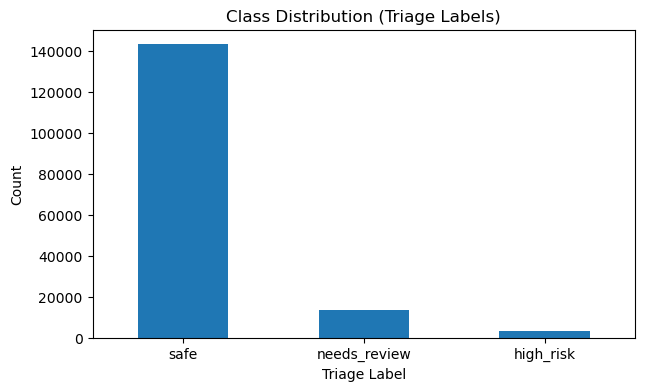

In [89]:
# Create a figure with specified dimensions (width=7, height=4 inches)
# This ensures the plot has enough space to be clearly visible
plt.figure(figsize=(7,4))

# Plot the triage counts as a bar chart
# The reindex() method reorders the categories in a logical sequence from least to most severe
# This makes the visualization more intuitive to interpret
triage_counts.reindex(["safe", "needs_review", "high_risk"]).plot(kind="bar")

# Add a title to the plot that describes what is being shown
plt.title("Class Distribution (Triage Labels)")

# Label the x-axis to indicate what the categories represent
plt.xlabel("Triage Label")

# Label the y-axis to indicate the unit of measurement
plt.ylabel("Count")

# Set the rotation of x-tick labels to 0 degrees (horizontal)
# This improves readability compared to the default angled labels
plt.xticks(rotation=0)

# Display the plot
# In Jupyter notebooks, this renders the visualization in the output cell
plt.show()

## Initial EDA Observation
- The dataset is imbalanced, with `safe` as the majority class.
- This matters because a model may over-predict the majority class.
- For this reason, **macro F1-score** will be used for baseline evaluation.


In [62]:
def clean_text(text):
    text = str(text)
    text = text.lower()
    
    # Replace URLs and emails (optional but useful)
    text = re.sub(r"http\S+|www\S+", " URL ", text)
    text = re.sub(r"\S+@\S+", " EMAIL ", text)
    
    # Replace line breaks / tabs
    text = re.sub(r"[\r\n\t]+", " ", text)
    
    # Normalize spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["comment_text_clean"] = df["comment_text"].astype(str).apply(clean_text)
df[["comment_text", "comment_text_clean"]].head(3)


,comment_text,comment_text_clean
0,Explanation\nWhy the edits made under my usern...,explanation why the edits made under my userna...
1,D'aww! He matches this background colour I'm s...,d'aww! he matches this background colour i'm s...
2,"Hey man, I'm really not trying to edit war. It...","hey man, i'm really not trying to edit war. it..."


In [90]:
def clean_text(text):
    """
    Clean and normalize text data for NLP processing.
    
    Args:
        text: Input text string to be cleaned
        
    Returns:
        str: Cleaned and normalized text
    """
    # Convert input to string type to handle any non-string inputs
    text = str(text)
    
    # Convert text to lowercase for consistency
    # This helps reduce dimensionality by treating "Word" and "word" as the same token
    text = text.lower()
    
    # Replace URLs with a standard placeholder token
    # This preserves the information that a URL was present while removing variable URL strings
    text = re.sub(r"http\S+|www\S+", " URL ", text)
    
    # Replace email addresses with a standard placeholder token
    # Similar to URLs, this standardizes email mentions while preserving their presence
    text = re.sub(r"\S+@\S+", " EMAIL ", text)
    
    # Remove line breaks, carriage returns, and tabs
    # These characters add noise to text analysis and should be normalized
    text = re.sub(r"[\r\n\t]+", " ", text)
    
    # Normalize multiple spaces to single spaces and trim leading/trailing whitespace
    # This creates consistent spacing throughout the text
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

# Apply the cleaning function to all comments and store in a new column
# This preserves the original text while creating a cleaned version for analysis
df["comment_text_clean"] = df["comment_text"].astype(str).apply(clean_text)

# Display a few examples to compare original and cleaned text
# This helps verify that the cleaning function is working as expected
df[["comment_text", "comment_text_clean"]].head(3)

,comment_text,comment_text_clean
0,Explanation\nWhy the edits made under my usern...,explanation why the edits made under my userna...
1,D'aww! He matches this background colour I'm s...,d'aww! he matches this background colour i'm s...
2,"Hey man, I'm really not trying to edit war. It...","hey man, i'm really not trying to edit war. it..."


In [91]:
# Calculate the total number of characters in each comment
# This provides a basic measure of comment length
df["char_count"] = df["comment_text"].astype(str).apply(len)

# Count the number of words in each comment by splitting on whitespace
# Word count is often more meaningful than character count for text analysis
df["word_count"] = df["comment_text"].astype(str).apply(lambda x: len(str(x).split()))

# Count exclamation marks, which can indicate emotional intensity or shouting
# High counts may correlate with toxic or inflammatory content
df["exclamation_count"] = df["comment_text"].astype(str).apply(lambda x: x.count("!"))

# Count question marks, which might indicate rhetorical questions or interrogative tone
# This can be a useful stylistic feature for classification
df["question_count"] = df["comment_text"].astype(str).apply(lambda x: x.count("?"))

# Count numeric digits in the text
# This can help identify comments with numbers, dates, or codes
df["digit_count"] = df["comment_text"].astype(str).apply(lambda x: sum(ch.isdigit() for ch in x))

# Count uppercase characters, which can indicate SHOUTING or emphasis
# Often associated with more emotional or aggressive text
df["uppercase_count"] = df["comment_text"].astype(str).apply(lambda x: sum(ch.isupper() for ch in x))

# Calculate the ratio of uppercase characters to total characters
# This normalizes the uppercase count by text length for better comparison
# The max() function prevents division by zero for empty comments
df["uppercase_ratio"] = df.apply(
    lambda r: r["uppercase_count"] / max(r["char_count"], 1), axis=1
)

# Define a list of the engineered feature columns for easy reference
feature_cols = [
    "char_count", "word_count", "exclamation_count", "question_count",
    "digit_count", "uppercase_count", "uppercase_ratio"
]

# Display the first few rows of the feature columns to inspect the results
df[feature_cols].head()

,char_count,word_count,exclamation_count,question_count,digit_count,uppercase_count,uppercase_ratio
0,264,43,0,1,9,17,0.064394
1,112,17,1,0,10,8,0.071429
2,233,42,0,0,0,4,0.017167
3,622,113,0,0,0,11,0.017685
4,67,13,0,1,0,2,0.029851


In [65]:
class_feature_summary = df.groupby("triage_label")[feature_cols].agg(["mean", "median"]).round(2)
display(class_feature_summary)


char_count        word_count        exclamation_count         \
                   mean median       mean median              mean median   
triage_label                                                                
high_risk        365.48  102.0      61.80   18.0              9.60    0.0   
needs_review     289.27  135.0      50.67   24.0              2.09    0.0   
safe             404.35  216.0      68.92   38.0              0.34    0.0   

             question_count        digit_count        uppercase_count         \
                       mean median        mean median            mean median   
triage_label                                                                   
high_risk              0.38    0.0        2.73    0.0          104.22    5.0   
needs_review           0.63    0.0        2.41    0.0           29.16    5.0   
safe                   0.43    0.0        3.40    0.0           14.24    7.0   

             uppercase_ratio         
                        mean median  
triage_label                         
high_risk               0.17   0.04  
needs_review            0.10   0.03  
safe                    0.04   0.03

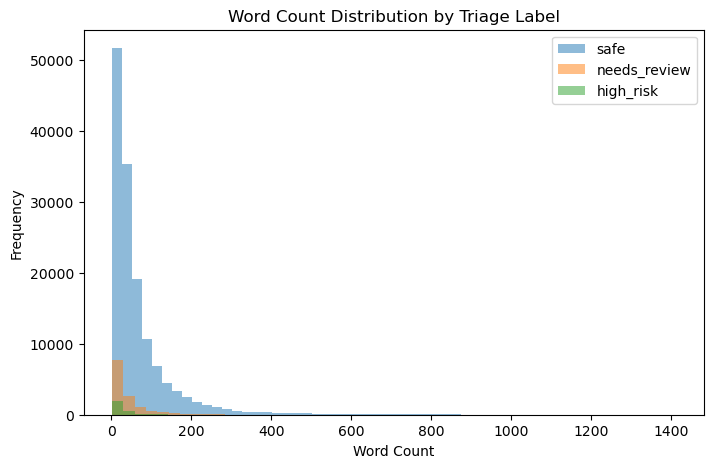

In [92]:
# Create a figure with specified dimensions (width=8, height=5 inches)
# This provides enough space for a clear visualization with multiple histograms
plt.figure(figsize=(8,5))

# Loop through each triage category to create overlapping histograms
for label in ["safe", "needs_review", "high_risk"]:
    # Create a subset of data containing only word counts for the current triage label
    # df.loc[] is used for conditional row selection based on the triage_label column
    subset = df.loc[df["triage_label"] == label, "word_count"]
    
    # Plot a histogram for this subset with:
    # - 50 bins to show detailed distribution
    # - alpha=0.5 for transparency so overlapping histograms are visible
    # - label parameter to identify this category in the legend
    plt.hist(subset, bins=50, alpha=0.5, label=label)

# Add a descriptive title to the plot
plt.title("Word Count Distribution by Triage Label")

# Label the x-axis to indicate what is being measured
plt.xlabel("Word Count")

# Label the y-axis to indicate the frequency scale
plt.ylabel("Frequency")

# Add a legend to distinguish between the different triage categories
# The legend will use the labels specified in the plt.hist() calls
plt.legend()

# Display the completed visualization
plt.show()

<Figure size 700x500 with 0 Axes>

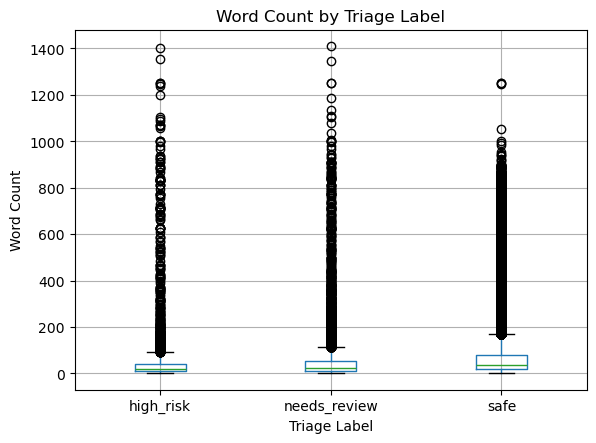

In [93]:
# Create a figure with specified dimensions (width=7, height=5 inches)
# This ensures the boxplot has enough space to be clearly visible
plt.figure(figsize=(7,5))

# Create boxplots of word count grouped by triage label
# Boxplots show the distribution's median, quartiles, and outliers
# This provides a statistical summary of word count across different categories
df.boxplot(column="word_count", by="triage_label")

# Set the main title for the plot
# This describes what the visualization is showing
plt.title("Word Count by Triage Label")

# Remove the default suptitle that pandas boxplot adds
# The empty string replaces the automatic "Boxplot grouped by triage_label" text
plt.suptitle("")

# Label the x-axis to indicate the grouping variable
plt.xlabel("Triage Label")

# Label the y-axis to indicate what is being measured
plt.ylabel("Word Count")

# Display the completed visualization
plt.show()

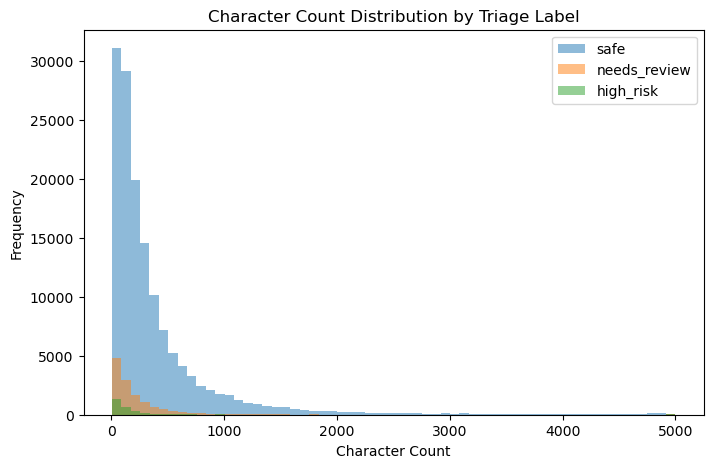

In [94]:
# Create a figure with specified dimensions (width=8, height=5 inches)
# This provides adequate space for a detailed histogram with multiple overlapping distributions
plt.figure(figsize=(8,5))

# Loop through each triage category to create separate histograms with the same binning
for label in ["safe", "needs_review", "high_risk"]:
    # Extract character counts only for comments with the current triage label
    # This creates a Series containing character counts for just one category
    subset = df.loc[df["triage_label"] == label, "char_count"]
    
    # Plot a histogram for this subset with:
    # - 60 bins for finer granularity in the distribution visualization
    # - alpha=0.5 for semi-transparency so overlapping distributions remain visible
    # - label parameter to identify this category in the legend
    plt.hist(subset, bins=60, alpha=0.5, label=label)

# Add a descriptive title explaining what the plot represents
plt.title("Character Count Distribution by Triage Label")

# Label the x-axis to indicate the measurement being displayed (character count)
plt.xlabel("Character Count")

# Label the y-axis to indicate frequency (count of comments)
plt.ylabel("Frequency")

# Add a legend to distinguish between the different triage categories
# The legend will use the labels and corresponding colors from the histogram plots
plt.legend()

# Display the completed visualization
plt.show()

In [95]:
def get_top_ngrams(texts, ngram_range=(1,1), top_n=20, min_df=5, stop_words="english"):
    """
    Extract and count the most frequent n-grams from a collection of texts.
    
    Args:
        texts: List or Series of text documents
        ngram_range: Tuple (min_n, max_n) for the range of n-gram sizes to consider
        top_n: Number of top n-grams to return
        min_df: Minimum document frequency (ignore terms that appear in fewer documents)
        stop_words: Whether to remove stop words ('english' for English stop words)
        
    Returns:
        DataFrame: Contains the top n-grams and their counts, sorted by frequency
    """
    # Convert input to pandas Series, remove NaN values, and ensure string type
    # This handles various input formats and ensures consistent processing
    texts = pd.Series(texts).dropna().astype(str)
    
    # Return empty DataFrame if there are no valid texts to process
    # This prevents errors when trying to vectorize an empty collection
    if len(texts) == 0:
        return pd.DataFrame(columns=["term", "count"])
    
    # Initialize the CountVectorizer with specified parameters:
    # - stop_words: Remove common words like "the", "and" if specified
    # - ngram_range: Extract single words (1,1), bigrams (2,2), or a range like (1,2)
    # - min_df: Ignore terms that appear in fewer than min_df documents
    vec = CountVectorizer(
        stop_words=stop_words,
        ngram_range=ngram_range,
        min_df=min_df
    )
    
    # Transform the text collection into a document-term matrix
    # Each row represents a document, each column represents a term
    X = vec.fit_transform(texts)
    
    # Sum the columns to get the total count for each term across all documents
    # Convert to a 1D array for easier processing
    freqs = np.asarray(X.sum(axis=0)).ravel()
    
    # Get the vocabulary (terms) that correspond to each column in the matrix
    terms = np.array(vec.get_feature_names_out())
    
    # Sort the terms by frequency in descending order and take the top_n
    # [::-1] reverses the array to get descending order
    top_idx = freqs.argsort()[::-1][:top_n]
    
    # Create a DataFrame with the top terms and their counts
    return pd.DataFrame({
        "term": terms[top_idx],
        "count": freqs[top_idx]
    })

In [96]:
# Loop through each triage category to analyze vocabulary differences
for label in ["safe", "needs_review", "high_risk"]:
    # Print a header indicating which category is being analyzed
    # The \n adds a blank line before each category for better readability
    print(f"\nTop unigrams for: {label}")
    
    # Extract and display the most common single words (unigrams) for this category
    # Steps:
    # 1. Filter the DataFrame to only include rows with the current triage label
    # 2. Pass the cleaned comment text from those rows to the get_top_ngrams function
    # 3. Configure the function to extract single words (ngram_range=(1,1))
    # 4. Request the top 20 most frequent terms
    # 5. Only include terms that appear in at least 5 documents (min_df=5)
    # 6. Display the resulting DataFrame with term and count columns
    display(
        get_top_ngrams(
            df.loc[df["triage_label"] == label, "comment_text_clean"],
            ngram_range=(1,1),
            top_n=20,
            min_df=5
        )
    )


Top unigrams for: safe


,term,count
0,article,55930
1,page,44000
2,wikipedia,42330
3,talk,35371
4,just,25082
5,like,24198
6,don,20686
7,think,18686
8,edit,17212
9,know,16773



Top unigrams for: needs_review


,term,count
0,like,3086
1,wikipedia,2815
2,just,2411
3,fuck,2404
4,don,2366
5,hate,2270
6,know,2082
7,page,2042
8,people,1741
9,moron,1679



Top unigrams for: high_risk


,term,count
0,fuck,7593
1,nigger,2975
2,suck,2584
3,ass,2243
4,shit,2072
5,fucking,1833
6,faggot,1743
7,fat,1681
8,die,1335
9,jew,1314


In [97]:
# Loop through each triage category to analyze common phrases
for label in ["safe", "needs_review", "high_risk"]:
    # Print a header indicating which category's bigrams are being displayed
    # The \n adds a blank line before each category for better readability
    print(f"\nTop bigrams for: {label}")
    
    # Extract and display the most common two-word phrases (bigrams) for this category
    # Steps:
    # 1. Filter the DataFrame to only include rows with the current triage label
    # 2. Pass the cleaned comment text from those rows to the get_top_ngrams function
    # 3. Configure the function to extract two-word phrases (ngram_range=(2,2))
    # 4. Request the top 20 most frequent bigrams
    # 5. Lower the minimum document frequency to 3 (min_df=3) since bigrams are naturally less frequent than single words
    # 6. Display the resulting DataFrame with bigram phrases and their counts
    display(
        get_top_ngrams(
            df.loc[df["triage_label"] == label, "comment_text_clean"],
            ngram_range=(2,2),
            top_n=20,
            min_df=3
        )
    )


Top bigrams for: safe


,term,count
0,talk page,12693
1,speedy deletion,4389
2,fair use,3143
3,don know,2580
4,feel free,2309
5,blocked editing,2306
6,talk contribs,2210
7,talk pages,2096
8,don think,2016
9,reliable sources,1879



Top bigrams for: needs_review


,term,count
0,hate hate,1570
1,moron hi,1298
2,hi moron,1298
3,wanker wanker,963
4,bullshit bullshit,833
5,talk page,603
6,aids aids,591
7,twat twat,483
8,know fggt,472
9,fggt know,471



Top bigrams for: high_risk


,term,count
0,fuck fuck,2821
1,nigger nigger,2035
2,ass ass,1127
3,suck suck,1126
4,faggot faggot,715
5,die die,640
6,fucker cocksucker,489
7,mothjer fucker,489
8,cocksucker mothjer,484
9,huge faggot,419


In [98]:
# Loop through each triage category to display representative examples
for label in ["safe", "needs_review", "high_risk"]:
    # Print a header with clear separation for each category
    # The formatting with === makes it easy to visually distinguish between categories
    print(f"\n=== Sample comments: {label} ===")
    
    # Randomly sample 5 comments from the current category
    # Using random_state=42 ensures reproducibility - the same examples will be shown each time
    samples = df.loc[df["triage_label"] == label, "comment_text"].sample(5, random_state=42)
    
    # Loop through the sampled comments with an index counter
    # The enumerate function adds a counter (i) starting at 1 for readability
    for i, txt in enumerate(samples, 1):
        # Print each comment with a number prefix
        # Limit to first 300 characters to avoid extremely long outputs
        # str() ensures the text is treated as a string even if there are other data types
        print(f"{i}. {str(txt)[:300]}")
        
        # Print a separator line of 80 dashes between comments
        # This creates clear visual separation between different comments
        print("-" * 80)


=== Sample comments: safe ===
1. "

Oh, don't worry about me, Sandstein. I'm of no strong opinion as to what is ""well."" Editing Wikipedia is not a personal benefit; if it were, I'd be COI! I do have some unfinished business, both with articles and ""arbitration or sanctions,"" such as the RfAr/Clarification and a dispute over my 
--------------------------------------------------------------------------------
2. Are you trying to dispute that fact?
--------------------------------------------------------------------------------
3. SWOT analysis 

This source – Align Technology, Inc. SWOT Analysis. (2013). 1-8. – is used 11 times, with no indication of how to find it or whether it's a primary source (I assume it is), so I'm going to remove anything sourced to it. Leaving this note in case there are objections.  (talk)
--------------------------------------------------------------------------------
4. cover 

so, do we want a current or older cover? i have the 57 paper edition i can s

## Outlier Analysis
For text datasets, unusually long comments can behave like outliers. They may represent copied discussions, repeated text, or formatting noise.  
Below, the notebook flags comments above the 99th percentile for `word_count` and `char_count` and inspects a few examples.


In [99]:
# Calculate the 99th percentile for word count
# This identifies a threshold above which comments are unusually long in terms of words
word_count_p99 = df["word_count"].quantile(0.99)

# Calculate the 99th percentile for character count
# This identifies a threshold above which comments are unusually long in terms of characters
char_count_p99 = df["char_count"].quantile(0.99)

# Create a subset of comments that exceed either the word count or character count thresholds
# The | operator represents logical OR - comments that exceed either threshold are included
# .copy() creates a new DataFrame to avoid SettingWithCopyWarning in pandas
outliers = df[
    (df["word_count"] > word_count_p99) |
    (df["char_count"] > char_count_p99)
].copy()

# Print the calculated 99th percentile thresholds with 2 decimal places
print(f"99th percentile - word_count: {word_count_p99:.2f}")
print(f"99th percentile - char_count: {char_count_p99:.2f}")

# Print the number of outliers and what percentage of the dataset they represent
# The :.2% format displays the proportion as a percentage with 2 decimal places
print(f"Number of potential outliers: {len(outliers)} ({len(outliers)/len(df):.2%} of rows)")

# Display the top 10 most extreme outliers
# Steps:
# 1. Select relevant columns for analysis
# 2. Sort by word_count and char_count in descending order to see the most extreme cases first
# 3. Take only the first 10 rows
# 4. Display the result in a formatted table
display(
    outliers[["triage_label", "word_count", "char_count", "comment_text"]]
    .sort_values(["word_count", "char_count"], ascending=False)
    .head(10)
)

99th percentile - word_count: 567.00
99th percentile - char_count: 3444.00
Number of potential outliers: 1711 (1.07% of rows)


,triage_label,word_count,char_count,comment_text
140904,needs_review,1411,4999,I AM AN LOSER ==== I AM AN LOSER == == I AM AN...
4712,high_risk,1403,4969,do go fuck off bastard\nDo Yyou Have a life?\n...
81295,high_risk,1354,4969,Take that! \n\nIN THE ASS IN THE ASS IN THE AS...
35817,needs_review,1344,4986,What is rong with you u pervert i ahte u just ...
27148,high_risk,1250,5000,DAMN YOU U CUNT DAMN YOU U CUNT DAMN YOU U CUN...
32143,needs_review,1250,4999,PIG PIG PIG PIG PIG PIG PIG PIG PIG PIG PIG PI...
61793,safe,1250,4999,OH NOES OH NOES OH NOES OH NOES OH NOES OH NOE...
76598,needs_review,1250,4999,DIE FAG DIE FAG DIE FAG DIE FAG DIE FAG DIE FA...
150039,safe,1250,4999,LOL LOL LOL LOL LOL LOL LOL LOL LOL LOL LOL LO...
136531,high_risk,1250,4687,SUCK MY COCK D SUCK MY COCK D SUCK MY COCK D S...


## EDA Findings
- The triage classes are imbalanced, with `safe` dominating the dataset.
- `high_risk` comments generally include stronger lexical signals.
- `needs_review` overlaps with both `safe` and `high_risk`, making it the most ambiguous class.
- Length-based features provide some signal but are not sufficient alone.
- N-gram patterns support the idea that lexical cues differ across classes, but ambiguity remains.


## Train/Test Split and Baseline Setup
A stratified split is used so each class is represented proportionally in the training and test sets.


In [74]:
X = df["comment_text_clean"]
y = df["triage_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).round(4))


Train size: 127656
Test size : 31915

Train class distribution:
triage_label
safe            0.8983
needs_review    0.0830
high_risk       0.0187
Name: proportion, dtype: float64


## Baseline Model Choice
**TF-IDF + Logistic Regression** is used as the baseline because it is a strong, interpretable, and widely used classical NLP benchmark for text classification. It is also fast to train and easy to compare against future models.


In [100]:
# Define the feature and target variables
# X contains the cleaned comment text that will be used for prediction
X = df["comment_text_clean"]

# y contains the triage labels that we want to predict
y = df["triage_label"]

# Split the dataset into training and testing sets
# Parameters:
# - test_size=0.20: Reserve 20% of the data for testing, 80% for training
# - random_state=42: Set a fixed random seed for reproducible results
# - stratify=y: Ensure that the class distribution is preserved in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Print the size of the training set to understand how much data is available for model training
print("Train size:", X_train.shape[0])

# Print the size of the test set to understand how much data will be used for evaluation
print("Test size :", X_test.shape[0])

# Print the class distribution in the training set
# normalize=True converts counts to proportions
# round(4) formats the output to 4 decimal places for readability
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).round(4))

Train size: 127656
Test size : 31915

Train class distribution:
triage_label
safe            0.8983
needs_review    0.0830
high_risk       0.0187
Name: proportion, dtype: float64


## Evaluation Metric Rationale
**Macro F1-score** is the primary metric because the triage classes are imbalanced. Macro F1 gives equal weight to each class, which makes it more appropriate than raw accuracy for assessing performance across `safe`, `needs_review`, and `high_risk`.


In [101]:
# Calculate the macro-averaged F1 score
# The macro F1 gives equal weight to each class regardless of its frequency
# This is important for imbalanced datasets where minority classes matter
macro_f1 = f1_score(y_test, y_pred, average="macro")

# Print the macro F1 score formatted to 4 decimal places
# This provides a single summary metric of model performance across all classes
print(f"Macro F1-score: {macro_f1:.4f}\n")

# Print a header for the detailed classification report
print("Classification Report:")

# Generate and print a comprehensive classification report
# The report includes precision, recall, and F1-score for each class
# Parameters:
# - y_test: The true labels from the test set
# - y_pred: The model's predicted labels
# - digits=4: Show metrics to 4 decimal places for precise evaluation
print(classification_report(y_test, y_pred, digits=4))

Macro F1-score: 0.6936

Classification Report:
              precision    recall  f1-score   support

   high_risk     0.4663    0.5327    0.4973       597
needs_review     0.5597    0.6847    0.6159      2648
        safe     0.9792    0.9562    0.9676     28670

    accuracy                         0.9257     31915
   macro avg     0.6684    0.7245    0.6936     31915
weighted avg     0.9348    0.9257    0.9296     31915



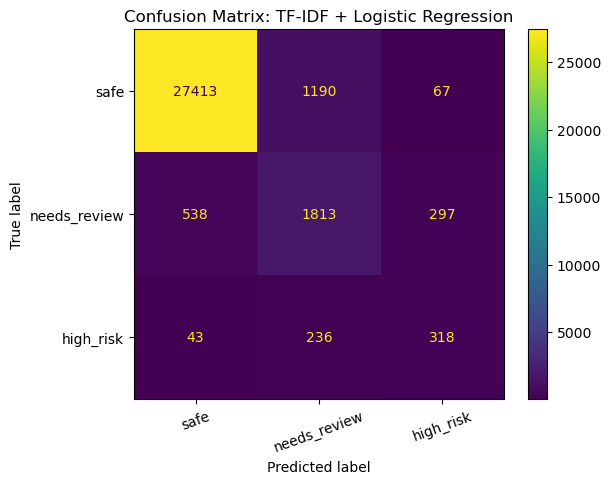

In [102]:
# Define the order of class labels for consistent display
# This ensures the confusion matrix rows and columns follow a logical sequence
labels = ["safe", "needs_review", "high_risk"]

# Calculate the confusion matrix using the test set results
# Parameters:
# - y_test: The true labels from the test set
# - y_pred: The model's predicted labels
# - labels: The specific order of labels to use
cm = confusion_matrix(y_test, y_pred, labels=labels)

# Create a ConfusionMatrixDisplay object with the calculated matrix and label names
# This prepares the visualization with appropriate row/column labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

# Generate the confusion matrix plot
# xticks_rotation=20 rotates the x-axis labels for better readability when labels are long
disp.plot(xticks_rotation=20)

# Add a title to the plot specifying the model type
# This helps identify which model's performance is being visualized
plt.title("Confusion Matrix: TF-IDF + Logistic Regression")

# Display the completed visualization
plt.show()

In [103]:
# Get probability estimates for each class from the model
# This returns an array where each row corresponds to a test example
# and each column represents the probability of belonging to a class
proba = baseline_model.predict_proba(X_test)

# Extract the class names from the trained classifier
# In a pipeline, the classifier is typically the last step, accessed via "clf"
# These names match the order of columns in the probability array
class_names = baseline_model.named_steps["clf"].classes_

# Create a DataFrame to store all prediction results and metadata
# This combines the original text, true labels, and predicted labels in one place
results = pd.DataFrame({
    "text": X_test.values,              # The original comment text
    "true_label": y_test.values,        # The actual triage category
    "pred_label": y_pred                # The model's predicted category
})

# Add the highest probability value for each prediction
# This indicates the model's confidence in its prediction
# Higher values suggest more confident predictions
results["max_prob"] = proba.max(axis=1)

# Add a boolean column indicating whether the prediction was correct
# This makes it easy to filter for correct or incorrect predictions
results["correct"] = (results["true_label"] == results["pred_label"])

# Add individual probability columns for each class
# This allows for detailed analysis of the model's decision-making
# Loop through each class and add its probability as a separate column
for idx, cls in enumerate(class_names):
    results[f"proba_{cls}"] = proba[:, idx]

# Display the first few rows of the results DataFrame
results.head()

,text,true_label,pred_label,max_prob,correct,proba_high_risk,proba_needs_review,proba_safe
0,attacks offsite has nothing to do with you fra...,safe,needs_review,0.615518,False,0.014898,0.615518,0.369585
1,2006 (utc) population groups i believe farting...,safe,safe,0.938900,True,0.006347,0.054753,0.938900
2,( please give me a postal address where i can ...,safe,safe,0.785621,True,0.020770,0.193609,0.785621
3,okay okay okay first off fuck you. second seco...,high_risk,needs_review,0.921238,False,0.056495,0.921238,0.022267
4,"actually, that means you didn't understand my ...",safe,safe,0.973243,True,0.000275,0.026483,0.973243


In [106]:
# Create a DataFrame containing only the misclassified examples
# Steps:
# 1. Filter the results DataFrame to keep only rows where "correct" is False (~results["correct"])
# 2. Create a copy to avoid potential SettingWithCopyWarning in pandas
# 3. Sort by the model's confidence (max_prob) in descending order
#    This shows the most confidently wrong predictions first
misclassified = results[~results["correct"]].copy().sort_values("max_prob", ascending=False)

# Print the total number of misclassified examples
# This gives a quick summary of how many errors the model made
print("Number of misclassified examples:", len(misclassified))

# Display the first 20 misclassifications with key information:
# - true_label: The actual category of the comment
# - pred_label: What the model predicted
# - max_prob: How confident the model was in its (incorrect) prediction
# - text: The actual comment content
# This provides a detailed view of the most problematic misclassifications
display(misclassified[["true_label", "pred_label", "max_prob", "text"]].head(20))

Number of misclassified examples: 2371


,true_label,pred_label,max_prob,text
29981,needs_review,high_risk,0.989866,"fuck me, because i'm gay"
30487,safe,high_risk,0.989672,a jew? or not a jew?
8739,needs_review,safe,0.988863,""" mfnickster, i am not sure if you have ever h..."
9128,high_risk,needs_review,0.988829,""" to bad germany didnt win the war, we wouldnt..."
15099,safe,needs_review,0.988300,what is up with you editing all this less than...
8900,needs_review,high_risk,0.986729,"hey gwernol, go suck a dick you fuckin piece o..."
12737,needs_review,high_risk,0.985815,fuck you mother fucker
18798,high_risk,needs_review,0.985134,you are fucking calling my talking on my own f...
21159,safe,high_risk,0.984048,and so what if she is a lesbian i am gay myself.
15389,needs_review,safe,0.981735,bold textthe many constructive editors of this...


In [108]:
# Sort the results DataFrame by confidence scores in ascending order
# This places the least confident predictions (lowest max_prob values) first
low_conf = results.sort_values("max_prob", ascending=True)

# Print a header explaining what the displayed data represents
# These are examples where the model is most uncertain about its predictions
print("Lowest-confidence predictions (potential human-review candidates):")

# Display the first 20 lowest-confidence predictions with key information:
# - true_label: The actual category of the comment
# - pred_label: What the model predicted
# - max_prob: How confident the model was (very low in these cases)
# - text: The actual comment content
# This provides examples of content that would be prioritized for human review
display(low_conf[["true_label", "pred_label", "max_prob", "text"]].head(20))

Lowest-confidence predictions (potential human-review candidates):


,true_label,pred_label,max_prob,text
27200,safe,needs_review,0.346803,and albanians have that white hat in the head ...
21397,safe,safe,0.347814,""" war vs rosales i added this moral war vs. ro..."
25987,safe,safe,0.349249,"how dare you!! i'll do what i want, when i wan..."
10800,safe,high_risk,0.350803,district of galicia was made into a nazi-upa c...
30585,needs_review,needs_review,0.366863,wooha reading your featured great article make...
16650,safe,safe,0.368203,live free or die trying!
12440,high_risk,needs_review,0.368420,bongwarrior ...is such a raging faggot. he doe...
10300,safe,high_risk,0.369632,""" congrats doc, i'll send the dog over to sit ..."
1762,high_risk,safe,0.371156,"objectivism hey walter, dont you remember me. ..."
23391,safe,high_risk,0.371419,puerto ricans are not white.. we are mixed peo...


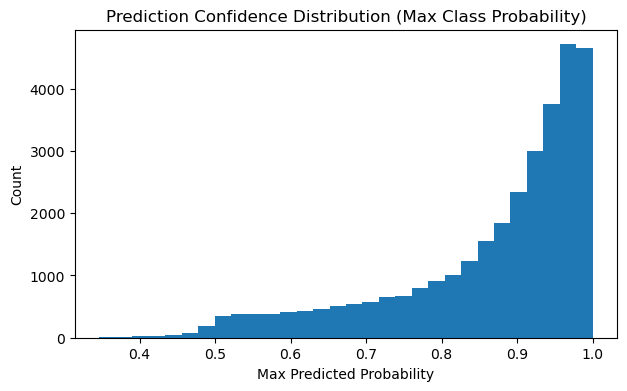

In [109]:
# Create a figure with specified dimensions (width=7, height=4 inches)
# This ensures the histogram has enough space to be clearly visible
plt.figure(figsize=(7,4))

# Create a histogram of the model's confidence scores (maximum probability for each prediction)
# The bins=30 parameter divides the probability range (0-1) into 30 equal intervals
# This provides a detailed view of how confidence is distributed
plt.hist(results["max_prob"], bins=30)

# Add a descriptive title explaining what the visualization represents
# This clarifies that we're looking at the model's confidence in its predictions
plt.title("Prediction Confidence Distribution (Max Class Probability)")

# Label the x-axis to indicate what the values represent
# These are the maximum probability values assigned to any class for each prediction
plt.xlabel("Max Predicted Probability")

# Label the y-axis to indicate the frequency scale
# This shows how many predictions fall into each confidence bin
plt.ylabel("Count")

# Display the completed visualization
plt.show()

In [107]:
# Set a confidence threshold for automatic decisions
# This value determines when the model's prediction is considered reliable enough
# Lower thresholds allow more automatic decisions but may increase errors
threshold = 0.60

# Create a new column for operational triage decisions that combines:
# 1. Model predictions when confidence is high (above threshold)
# 2. Automatic "needs_review" flag when confidence is low (below threshold)
# 
# np.where works like an if-else statement:
# - If max_prob < threshold: assign "needs_review"
# - Otherwise: use the model's prediction
results["operational_triage"] = np.where(
    results["max_prob"] < threshold,
    "needs_review",
    results["pred_label"]
)

# Count how many comments fall into each operational triage category
# This shows the practical distribution of work after applying the confidence threshold
results["operational_triage"].value_counts()

operational_triage
safe            26945
needs_review     4455
high_risk         515
Name: count, dtype: int64

## Baseline Model Conclusions
- A classical NLP pipeline (**TF-IDF + Logistic Regression**) provides a strong and interpretable baseline.
- The model performs better on clear examples and struggles more on ambiguous boundary cases.
- The `needs_review` class is the most difficult due to overlap with both `safe` and `high_risk`.
- Confidence-based routing is a practical extension for a human-in-the-loop moderation workflow.

## Next Steps 
- Try additional models (e.g., Linear SVM, Naive Bayes, transformer baseline if feasible)
- Improve text preprocessing and feature engineering
- Tune thresholds for human review routing
- Improve presentation for technical and non-technical audiences


## Results (EDA + Baseline)

### EDA Summary
- Loaded and analyzed the Jigsaw toxic comment dataset.
- Created a triage mapping for the capstone objective: `safe`, `needs_review`, and `high_risk`.
- Performed EDA on class balance, text length, and n-gram patterns.
- Observed class imbalance and lexical overlap, especially around the `needs_review` class.

### Baseline Model
- Trained a baseline classifier using **TF-IDF + Logistic Regression**.
- Evaluated using **macro F1-score**, classification report, and confusion matrix.
- Baseline performs well on clearer examples and struggles with ambiguous cases, which supports the human-in-the-loop review design.

### Next Steps
- Add additional models and comparisons.
- Refine feature engineering and uncertainty-based routing.
- Improve notebook and README presentation for final capstone submission.
